In [1]:
import numpy as np
import pandas as pd
import missingno as msno
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df1 = pd.read_csv(r"C:\Users\niraj\OneDrive\Desktop\Academics\Hack-a-thons\DecodeX\OneDrive-2025-02-13\CPMNT.csv")
df2 = pd.read_csv(r"C:\Users\niraj\OneDrive\Desktop\Academics\Hack-a-thons\DecodeX\OneDrive-2025-02-13\CPASF.csv")

In [56]:
#df1.shape

In [39]:
#df2.shape

In [3]:
df1.isnull().sum() * 100/len(df1)

Key              0.000000
Date             0.000000
Locations        0.000000
C&F Agent        0.000000
Division         0.000000
SKU              0.000000
Sales            0.000000
OpeningStock     0.000000
Receipts         0.000000
Forecast         0.000000
SellingPrice    40.714971
dtype: float64

In [4]:
df2.isnull().sum() * 100/len(df2)

Key             0.000000
Date            0.000000
Locations       0.000000
C&F Agent       0.000000
Division        0.000000
SKU             0.000000
Sales           0.000000
OpeningStock    0.000000
Receipts        0.000000
Forecast        0.000000
SellingPrice    8.751183
dtype: float64

In [5]:
# Convert the 'Date' column to datetime format
df1['Date'] = pd.to_datetime(df1['Date'], format='%b-%y')
#df1.head(20)

In [6]:
df1 = df1.sort_values(by='Date')
#df1.head(60)

In [13]:
df1.head()

,Key,Date,Locations,C&F Agent,Division,SKU,Sales,OpeningStock,Receipts,Forecast,SellingPrice
0,37987AHMEDABAD AGENT 2PROD E,2004-01-01,AHMEDABAD BRANCH,AHMEDABAD AGENT 2,CPMNT,PROD E,94560,90560,43680,83638,NaN
3129,37987KANPUR AGENT 1PROD D,2004-01-01,KANPUR BRANCH,KANPUR AGENT 1,CPMNT,PROD D,8400,400,11200,11828,NaN
811,37987ZIRAKPUR AGENT 1PROD E,2004-01-01,ZIRAKPUR BRANCH,ZIRAKPUR AGENT 1,CPMNT,PROD E,42720,5948,72480,36000,NaN
3093,37987HYDERABAD AGENT 1PROD D,2004-01-01,HYDERABAD BRANCH,HYDERABAD AGENT 1,CPMNT,PROD D,43200,0,43200,18196,NaN
3057,37987GHAZIABAD AGENT 1PROD D,2004-01-01,GHAZIABAD BRANCH,GHAZIABAD AGENT 1,CPMNT,PROD D,8800,1200,11200,7279,NaN


## correlation between numeric features

In [16]:
from sklearn.impute import SimpleImputer
import numpy as np
import scipy.stats as stats

numeric_df1 = df1.drop(['Key', 'Date', 'Locations', 'C&F Agent', 'Division', 'SKU'],axis =1)
numeric_df1.corr()

,Sales,OpeningStock,Receipts,Forecast,SellingPrice
Sales,1.000000,0.595603,0.925167,0.923030,-0.318719
OpeningStock,0.595603,1.000000,0.532344,0.606823,-0.205716
Receipts,0.925167,0.532344,1.000000,0.868924,-0.308512
Forecast,0.923030,0.606823,0.868924,1.000000,-0.317000
SellingPrice,-0.318719,-0.205716,-0.308512,-0.317000,1.000000


In [18]:
df1 = df1.sort_values(by=["C&F Agent", "SKU", "Date"])

#### If you're using the data for forecasting, incorrect imputations can lead to poor predictions.

In [20]:
df1['Year'] = df1['Date'].dt.year

### Below is the total number of sales we have of each product in each year

In [22]:
ttl_count_per_year1 = df1.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.count())
ttl_count_per_year1

Year  SKU   
2004  PROD A    125
      PROD B     77
      PROD C    164
      PROD D     93
      PROD E    123
2005  PROD A    162
      PROD B    205
      PROD C    209
      PROD D    148
      PROD E    164
2006  PROD A    184
      PROD B    256
      PROD C    205
      PROD D    176
      PROD E    180
Name: SellingPrice, dtype: int64

### Below is the number of rows with missing selling price for each product in each year

In [24]:
nan_count_per_year = df1.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.isna().sum())
nan_count_per_year

Year  SKU   
2004  PROD A    151
      PROD B    135
      PROD C    112
      PROD D    183
      PROD E    153
2005  PROD A    115
      PROD B     69
      PROD C     67
      PROD D    128
      PROD E    112
2006  PROD A    112
      PROD B     38
      PROD C     89
      PROD D    118
      PROD E    115
Name: SellingPrice, dtype: int64

In [27]:
#!pip install statsmodels pandas numpy matplotlib

In [29]:
df1.set_index('Date', inplace=True)

## below is time series of sorted data by agent, product and date yearly

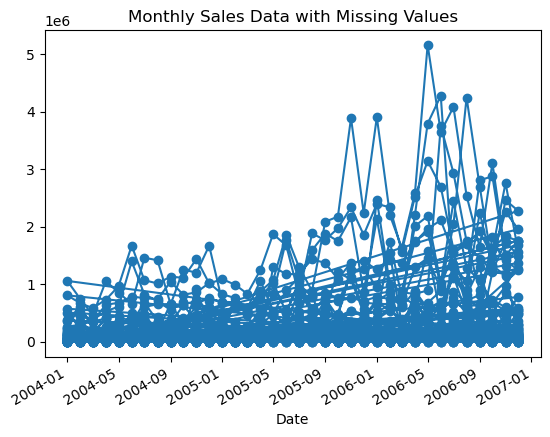

In [31]:
df1['Sales'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

### Below each is the time series of selling price yearly

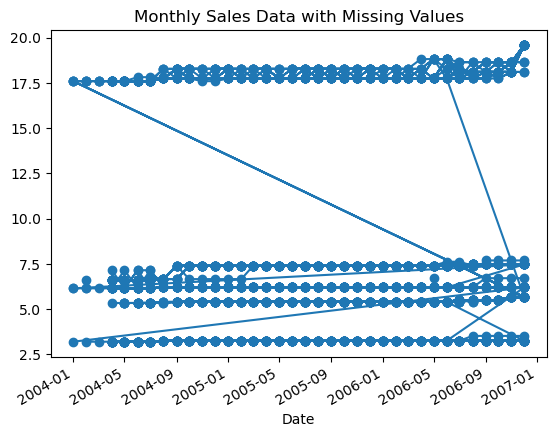

In [33]:
df1['SellingPrice'].plot(title="Monthly Sales Data with Missing Values", marker='o')
plt.show()

## Below is the time series of sorted data, yearly, for each product separately 

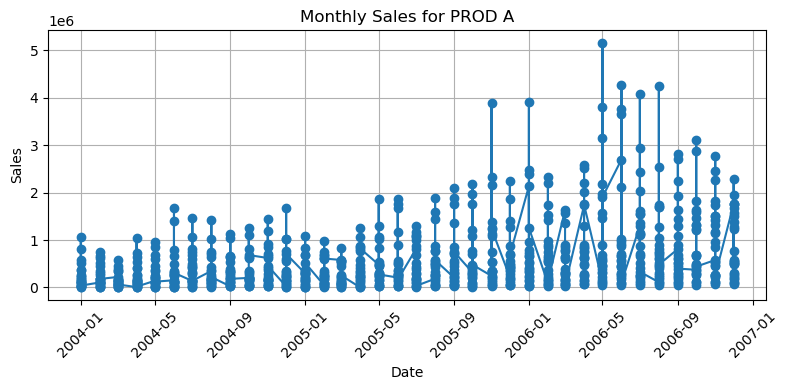

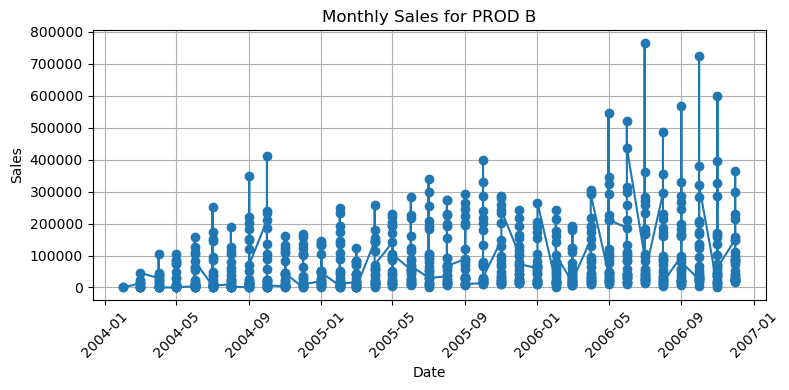

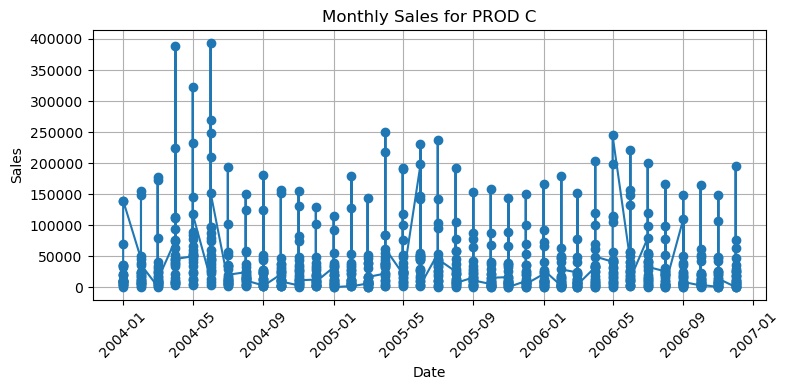

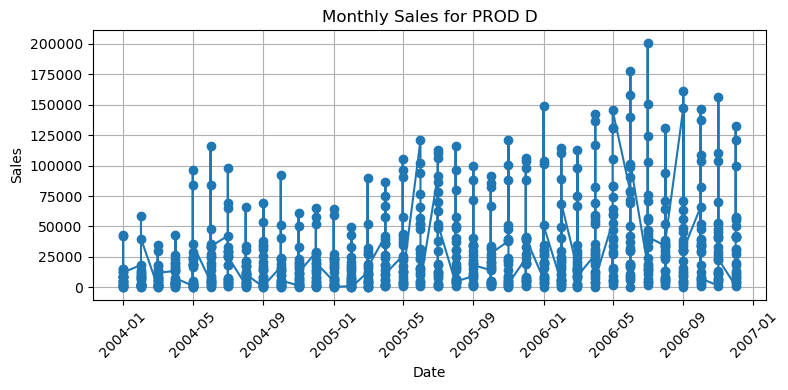

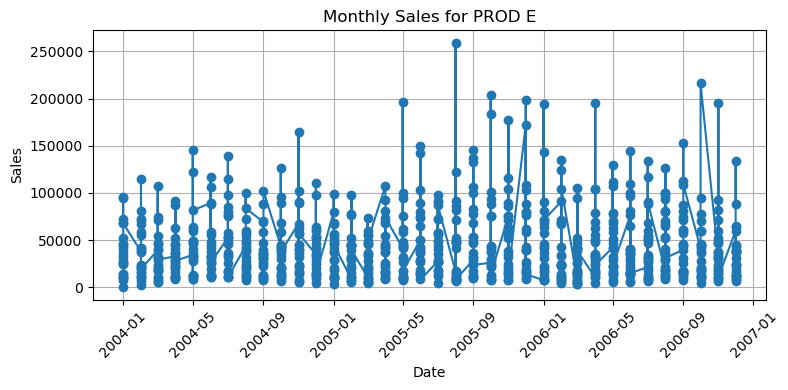

In [35]:
sku_list = df1['SKU'].unique()

for sku in sku_list:
    df_sku = df1[df1['SKU'] == sku].sort_index()  # Sort by index since Date is index
    plt.figure(figsize=(8, 4))
    plt.plot(df_sku.index, df_sku['Sales'], marker='o')  # use index instead of 'Date'
    plt.title(f"Monthly Sales for {sku}")
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


- ✅ ffill() – Forward Fill
Fills the missing value with the last known non-null value above it.

- ✅ bfill() – Backward Fill
Fills the missing value with the next known non-null value below it.

- ✅ Why Use Both?
Using both ensures:

Missing values at the start of a group (which ffill can’t fill) are handled by bfill.

Missing values at the end of a group (which bfill can’t fill) are handled by ffill.

This gives you the maximum fill coverage for your time series.

- ⚠️Using Both ffill().bfill() Can Disrupt the Trend
When you apply ffill().bfill() to fill missing values at the start and end of a time series:

It propagates existing values into periods where no information actually exists.

This can flatten the trend or introduce false stability, especially:

At the start: when the series begins with NaNs → bfill fills them using future data (cheating for forecasting).

At the end: ffill fills NaNs using past data → can hide a downward or upward trend.

- ✅ Correct Strategy
You can first use ffill(), and then apply bfill() only to values still missing after forward fill.

This way:

You preserve realistic trend continuity

You only fill what’s absolutely necessary (e.g., at the start of the series)

In [43]:
#df1['SellingPrice'] = df1['SellingPrice'].fillna(method='ffill')

In [41]:
#df1['SellingPrice'] = df1['SellingPrice'].fillna(method='bfill')

# SAME FOR DF2

In [45]:
# Convert the 'Date' column to datetime format
df2['Date'] = pd.to_datetime(df2['Date'], format='%b-%y')
#df2.head(20)

In [47]:
df2 = df2.sort_values(by='Date')
#df2.head(60)

In [49]:
df2 = df2.sort_values(by=["C&F Agent", "SKU", "Date"])

In [51]:
df2['Year'] = df2['Date'].dt.year

In [53]:
ttl_count_per_year2 = df2.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.count())
ttl_count_per_year2

Year  SKU   
2004  PROD A    213
      PROD B    209
      PROD C    208
      PROD D    209
      PROD E    209
2005  PROD A    261
      PROD B    270
      PROD C    276
      PROD D    274
      PROD E    276
2006  PROD A    283
      PROD B    290
      PROD C    294
      PROD D    294
      PROD E    292
Name: SellingPrice, dtype: int64

In [55]:
nan_count_per_year2 = df2.groupby(['Year','SKU'])['SellingPrice'].apply(lambda x: x.isna().sum())
nan_count_per_year2

Year  SKU   
2004  PROD A    63
      PROD B    65
      PROD C    68
      PROD D    67
      PROD E    67
2005  PROD A    15
      PROD B     6
      PROD C     0
      PROD D     2
      PROD E     0
2006  PROD A    11
      PROD B     4
      PROD C     1
      PROD D     0
      PROD E     1
Name: SellingPrice, dtype: int64

In [57]:
df2.set_index('Date', inplace=True)

In [61]:
#df2['SellingPrice'] = df2['SellingPrice'].fillna(method='ffill')

In [65]:
#df2['SellingPrice'] = df2['SellingPrice'].fillna(method='bfill')

In [197]:
#df2.isnull().sum()

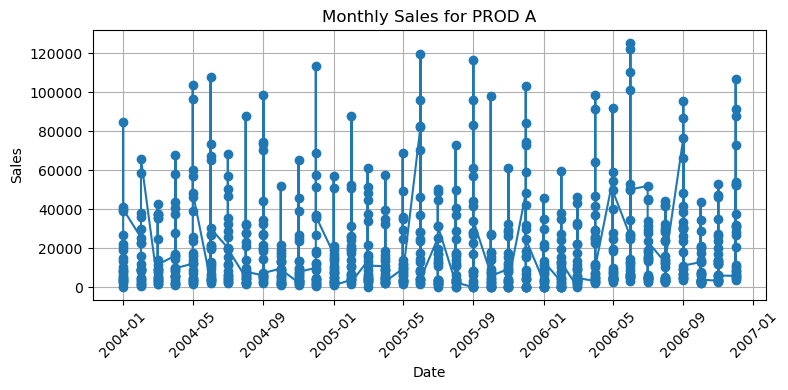

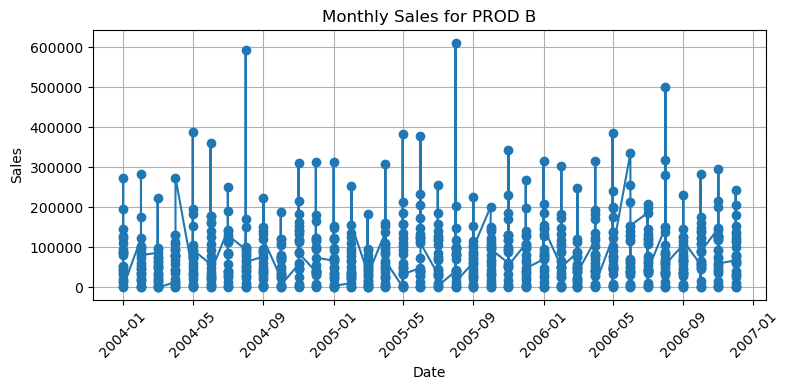

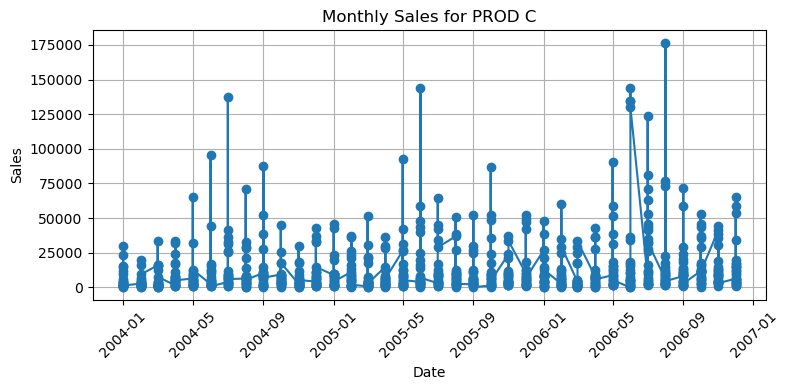

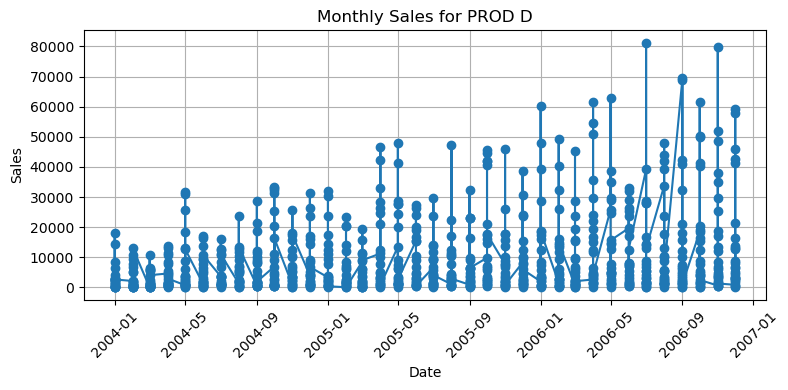

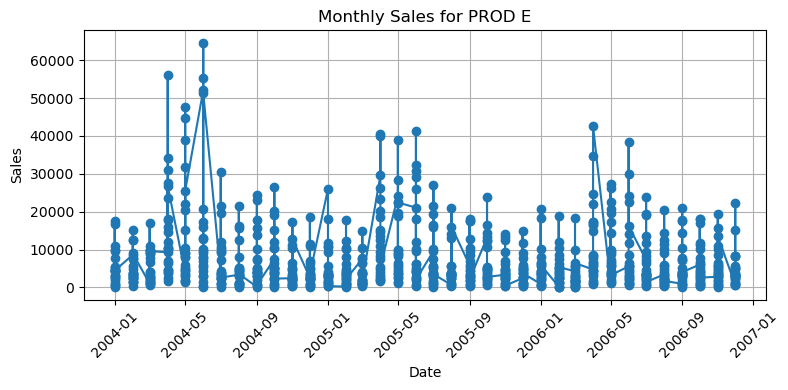

In [67]:
sku_list = df2['SKU'].unique()

for sku in sku_list:
    df_sku = df2[df2['SKU'] == sku].sort_index()  # Sort by index since Date is index
    plt.figure(figsize=(8, 4))
    plt.plot(df_sku.index, df_sku['Sales'], marker='o')  # use index instead of 'Date'
    plt.title(f"Monthly Sales for {sku}")
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Seasonal Decomposition

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\2661279477.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD A


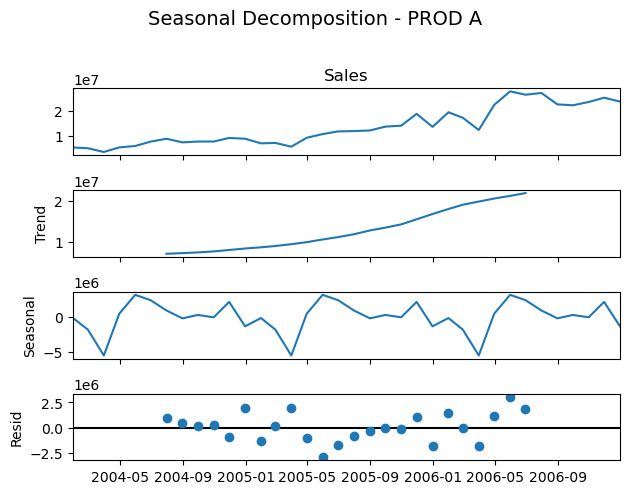

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\2661279477.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD E


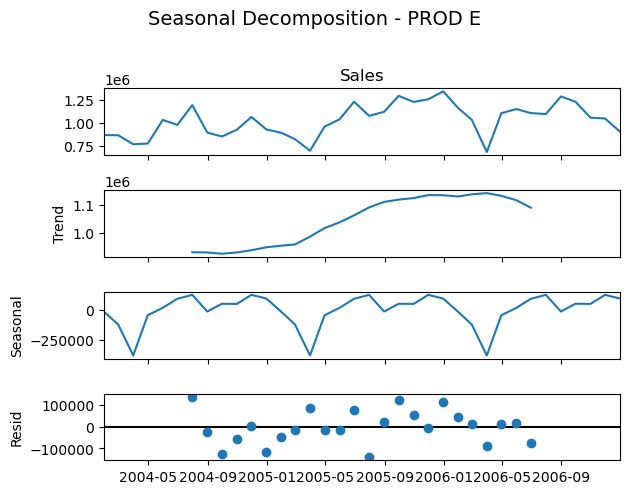

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\2661279477.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD D


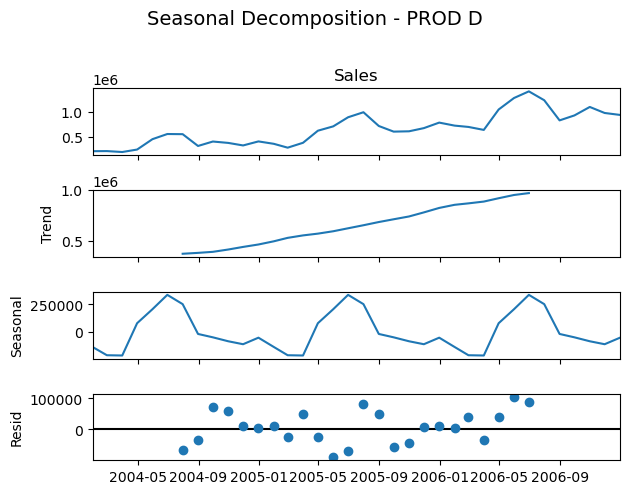

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\2661279477.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD C


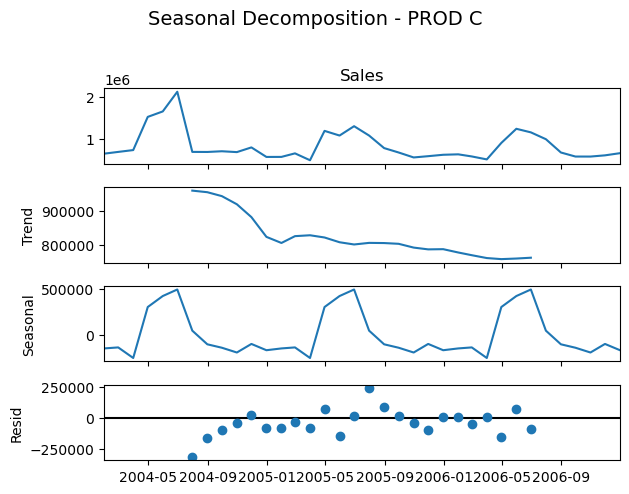

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\2661279477.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD B


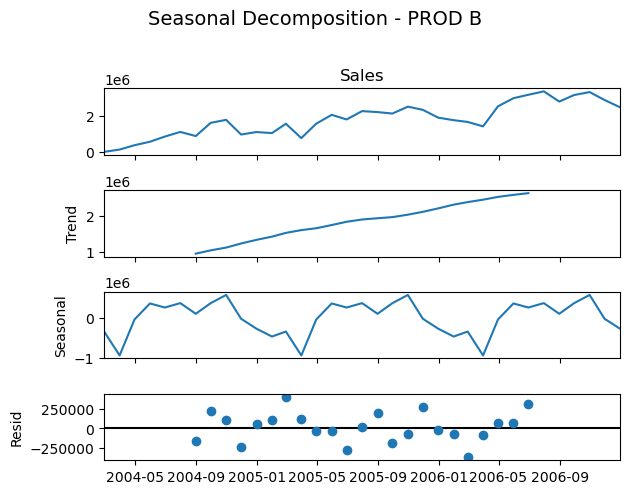

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Ensure the index is monthly and continuous
df1 = df1.sort_index()
sku_list = df1['SKU'].unique()

for sku in sku_list:
    # Filter data for current SKU
    df_sku = df1[df1['SKU'] == sku]['Sales']

    # Resample to monthly frequency and fill missing months (if any)
    df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()

    # Skip short series (<24 months)
    if len(df_sku_monthly) < 24:
        print(f"Skipping {sku} — not enough data for decomposition")
        continue

    # Decompose
    result = seasonal_decompose(df_sku_monthly, model='Additive', period=12)

    # Plot
    print(f"Seasonal Decomposition for SKU: {sku}")
    result.plot()
    plt.suptitle(f'Seasonal Decomposition - {sku}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\1719459378.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD A


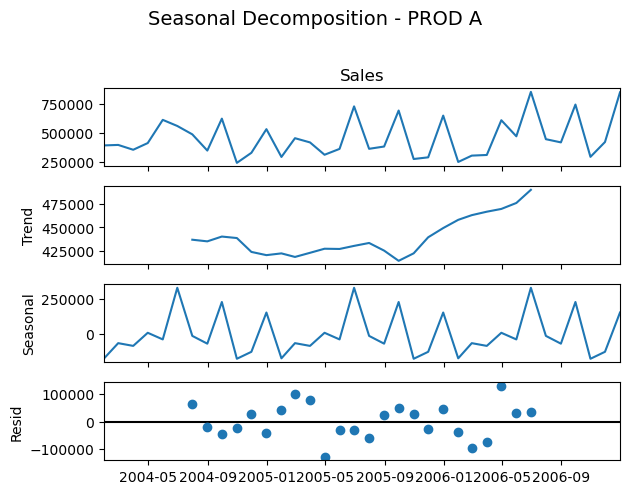

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\1719459378.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD D


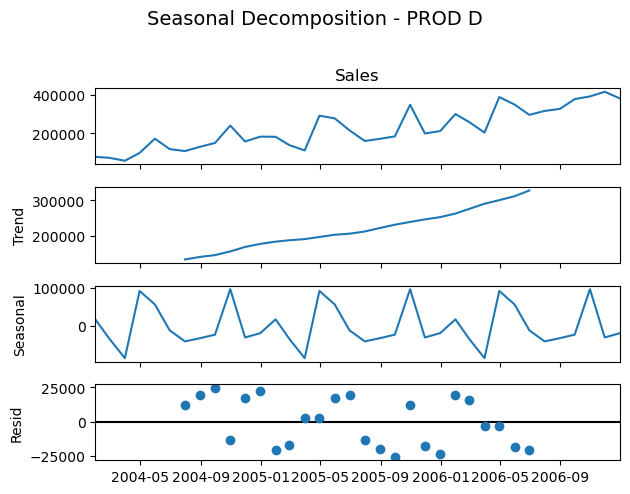

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\1719459378.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD C


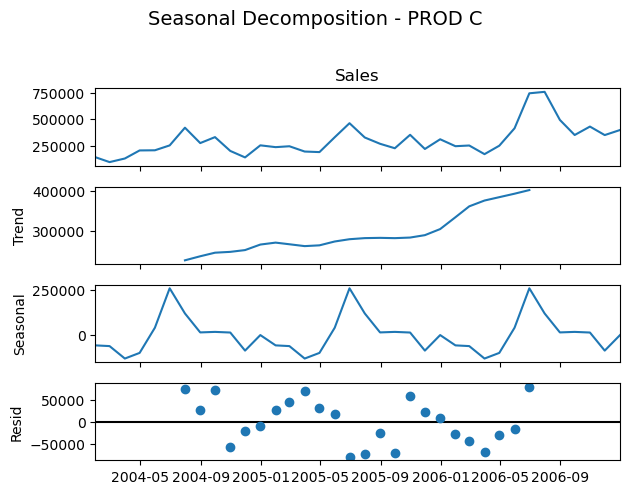

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\1719459378.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD B


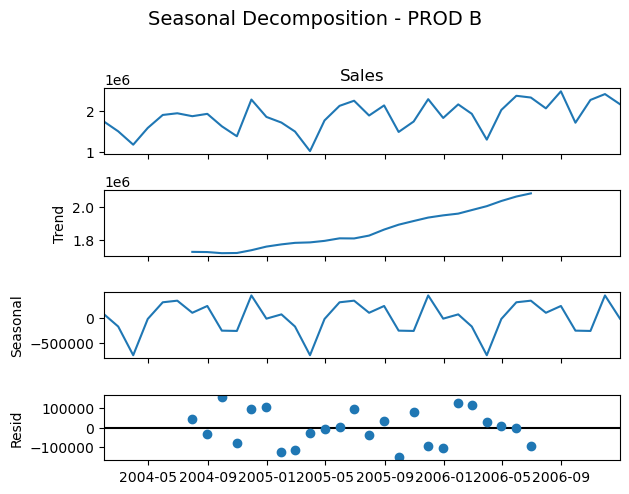

C:\Users\niraj\AppData\Local\Temp\ipykernel_12756\1719459378.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()


Seasonal Decomposition for SKU: PROD E


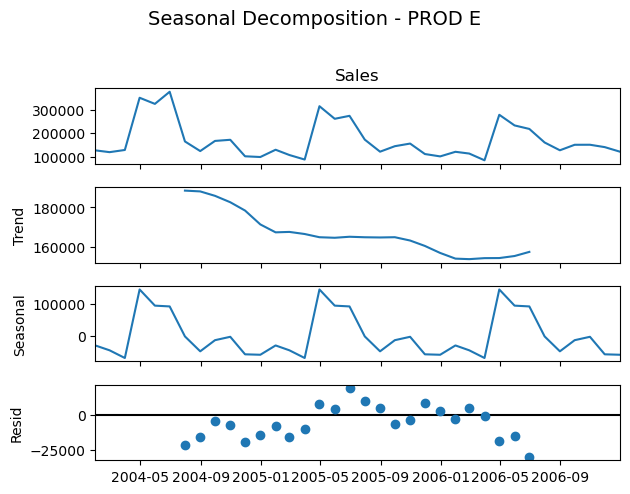

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Ensure the index is monthly and continuous
df2 = df2.sort_index()
sku_list = df2['SKU'].unique()

for sku in sku_list:
    # Filter data for current SKU
    df_sku = df2[df2['SKU'] == sku]['Sales']

    # Resample to monthly frequency and fill missing months (if any)
    df_sku_monthly = df_sku.resample('M').sum().ffill().bfill()

    # Skip short series (<24 months)
    if len(df_sku_monthly) < 24:
        print(f"Skipping {sku} — not enough data for decomposition")
        continue

    # Decompose
    result = seasonal_decompose(df_sku_monthly, model='Additive', period=12)

    # Plot
    print(f"Seasonal Decomposition for SKU: {sku}")
    result.plot()
    plt.suptitle(f'Seasonal Decomposition - {sku}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='SKU', ylabel='Sales'>

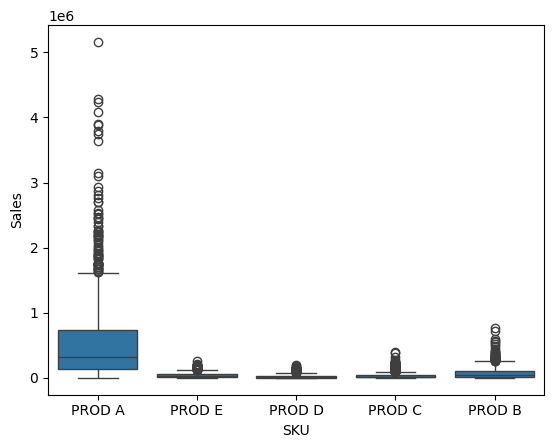

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='SKU', y='Sales', data=df1)


<Axes: xlabel='SKU', ylabel='Sales'>

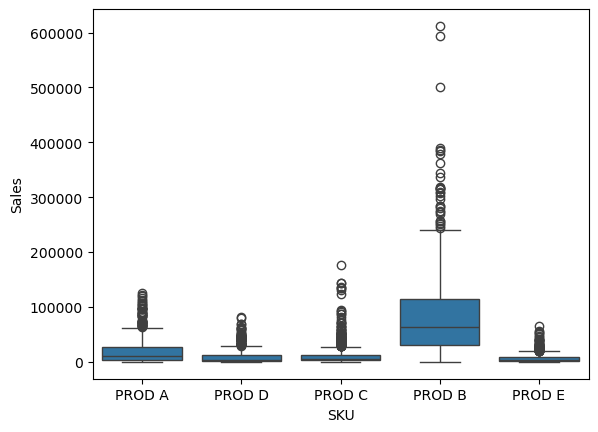

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='SKU', y='Sales', data=df2)

# ACF and PACF

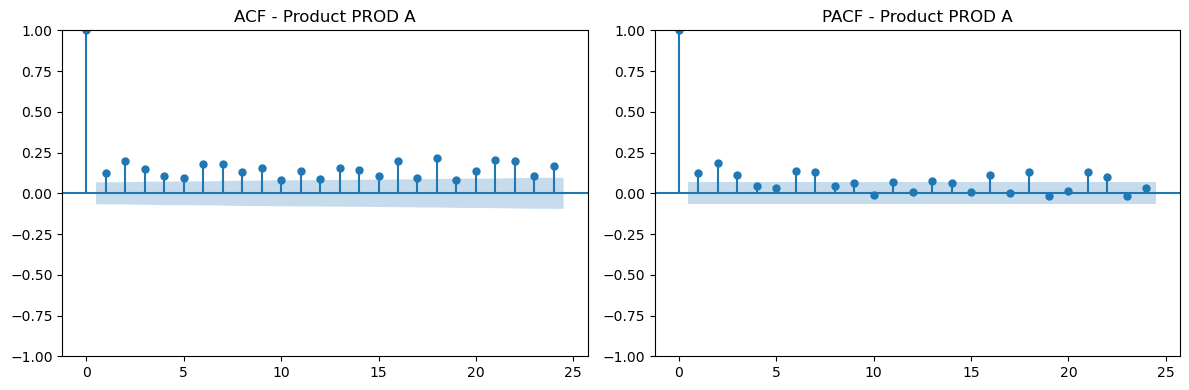

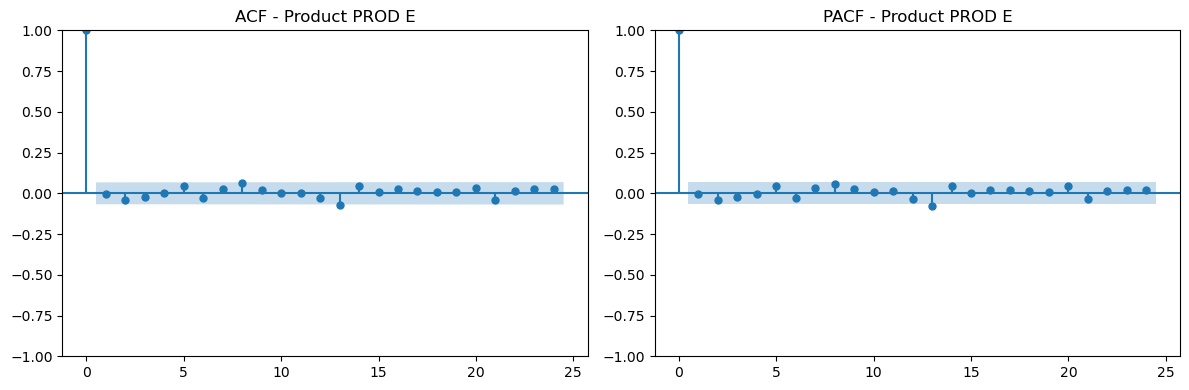

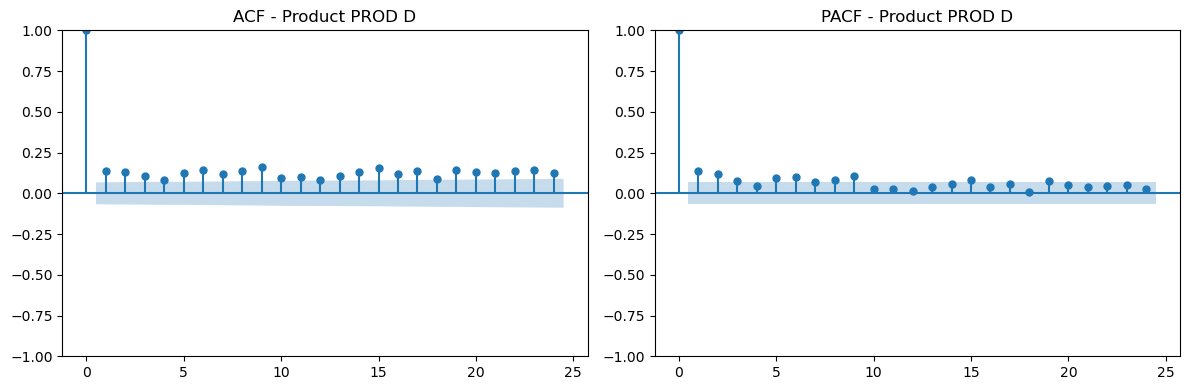

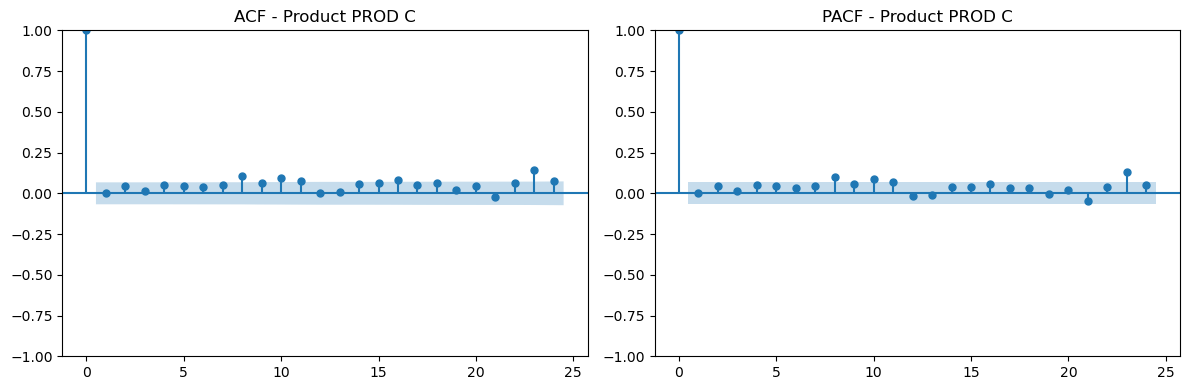

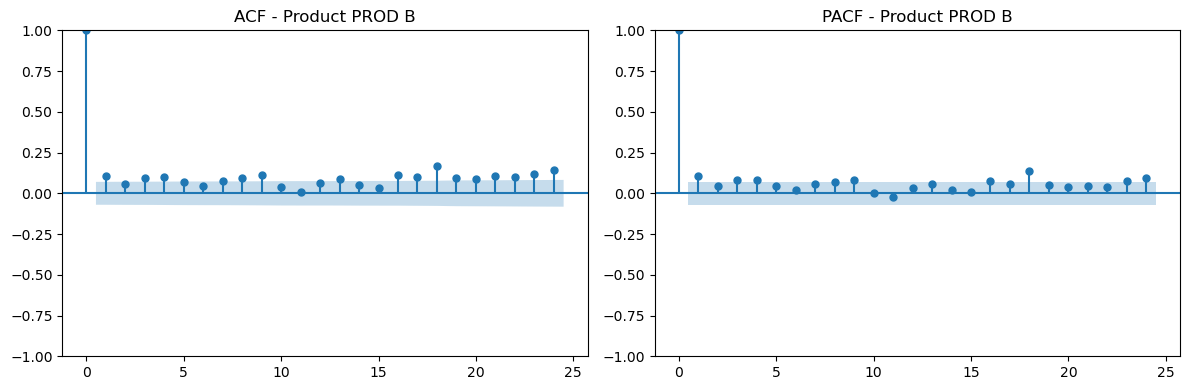

In [107]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

product_ids = df1['SKU'].unique()

for product_id in product_ids:
    series = df1[df1['SKU'] == product_id]['Sales']  # or 'Sales'
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(), ax=axes[0], lags=24)
    plot_pacf(series.dropna(), ax=axes[1], lags=24)

    axes[0].set_title(f'ACF - Product {product_id}')
    axes[1].set_title(f'PACF - Product {product_id}')
    plt.tight_layout()
    plt.show()


# Rolling and Trailing mean

In [119]:
import matplotlib.pyplot as plt

def plot_smoothed_series(df1, product_col='SKU', value_col='Sales', window=12):
    """
    Plots original, rolling, and trailing means for each product.

    Parameters:
    - df: DataFrame with datetime index, a product column, and sales values
    - product_col: name of the column identifying product
    - value_col: name of the column to smooth (e.g., Sales_cleaned)
    - window: size of rolling/trailing window (e.g., 3 months)
    """
    product_ids = df1[product_col].unique()

    for product_id in product_ids:
        df_prod = df1[df1[product_col] == product_id].copy()
        series = df_prod[value_col]

        # Rolling and trailing means
        rolling_mean = series.rolling(window=window, center=True).mean()
        trailing_mean = series.rolling(window=window, center=False).mean()

        # Plot
        plt.figure(figsize=(12, 5))
        plt.plot(series, label='Original', color='blue', alpha=0.6)
        plt.plot(rolling_mean, label=f'Rolling Mean ({window})', color='orange')
        plt.plot(trailing_mean, label=f'Trailing Mean ({window})', color='green', linestyle='--')

        plt.title(f"Smoothed Sales for Product {product_id}")
        plt.xlabel("Date")
        plt.ylabel("Sales")
        plt.legend()
        plt.tight_layout()
        plt.show()


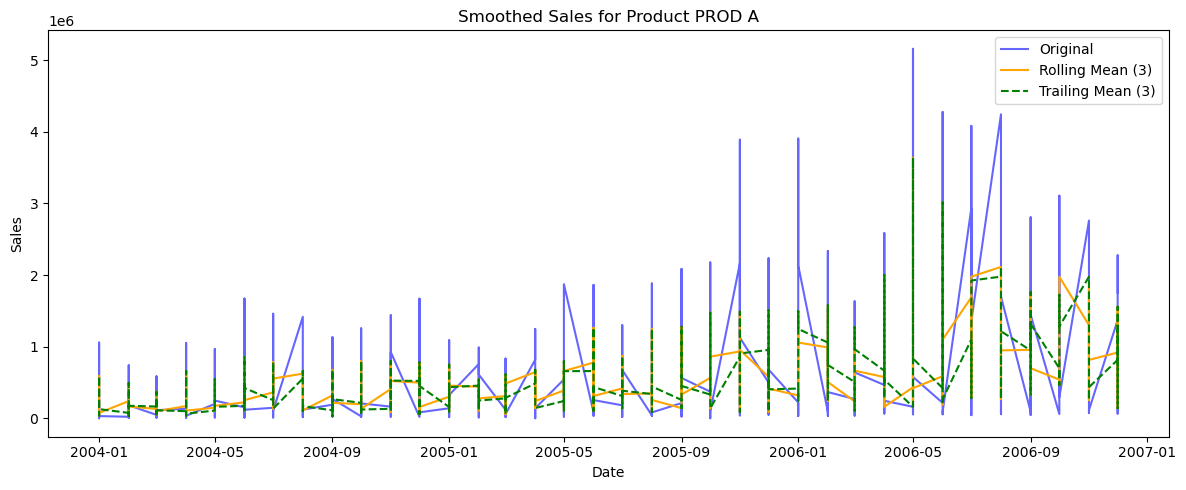

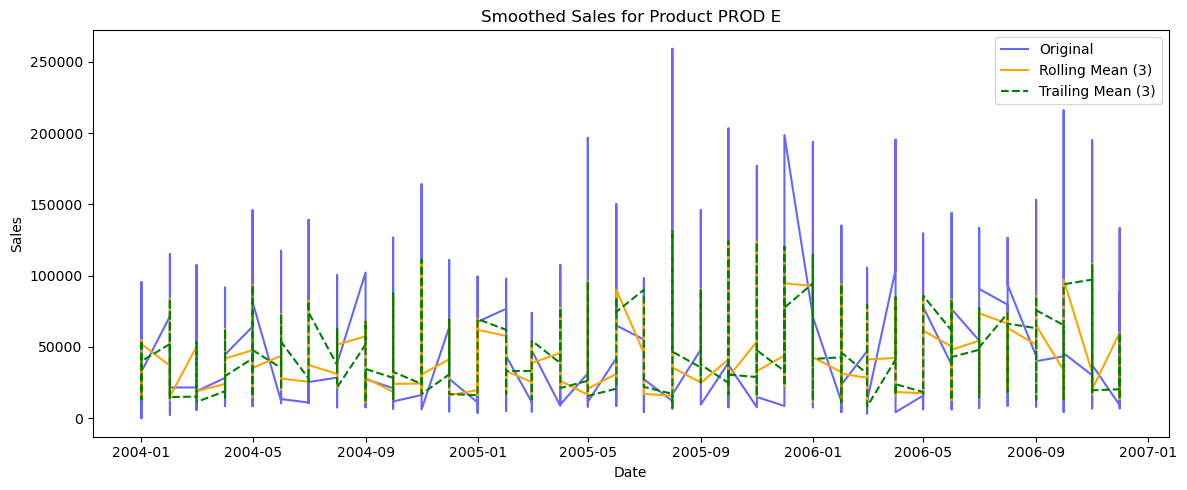

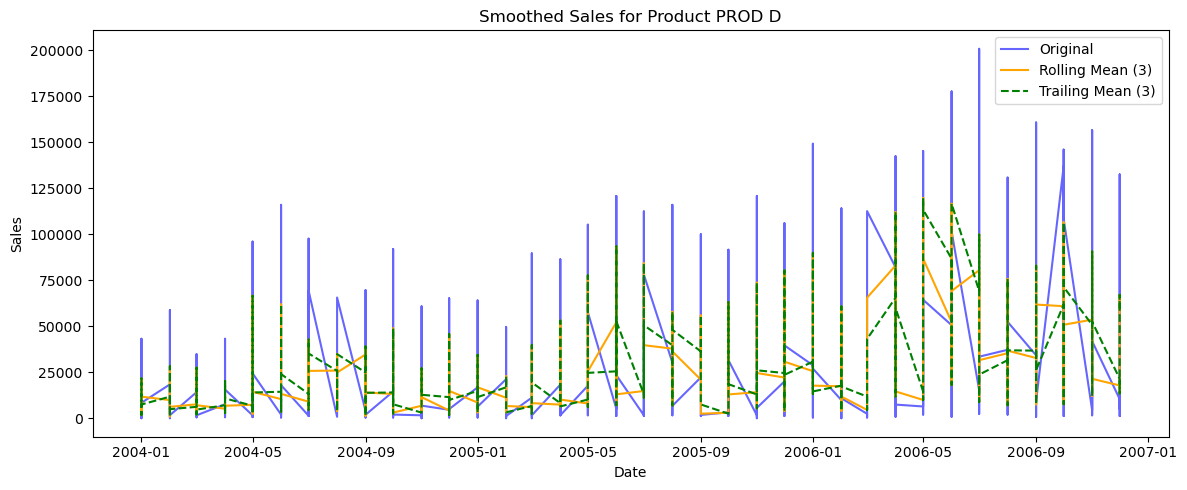

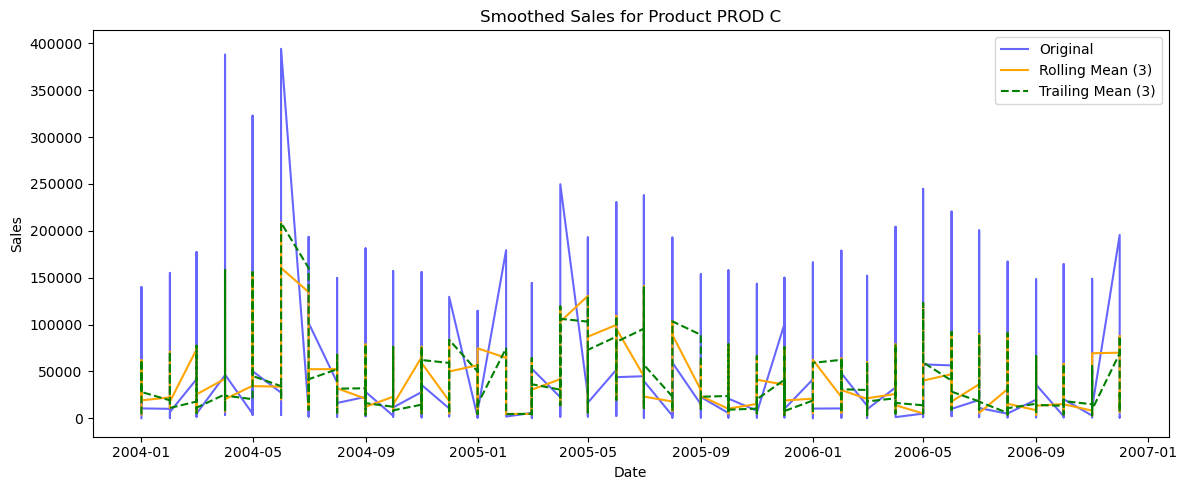

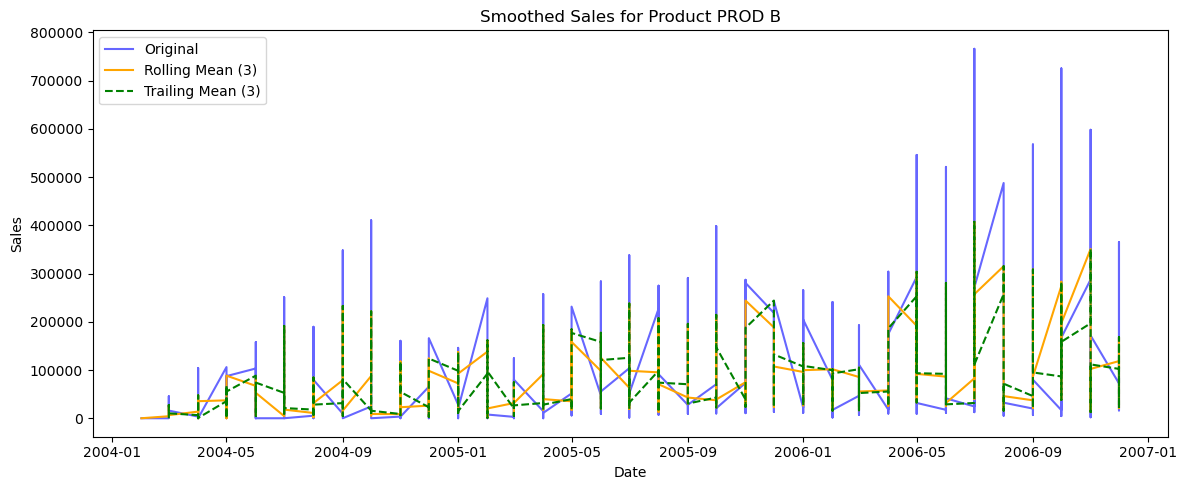

In [121]:
plot_smoothed_series(df1, product_col='SKU', value_col='Sales', window=3)

## your "original" series is very spiky, so even the rolling and trailing means look jagged, and you're not getting smooth, interpretable curves.

## Holt's winter plots

In [145]:
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def plot_holt_winters_per_product(df1, product_col='SKU', value_col='Sales_cleaned', seasonal_periods=12):
    """
    Plots Holt-Winters smoothing for each product based only on Sales_cleaned.

    Parameters:
    - df: DataFrame with datetime index
    - product_col: column name for product/SKU
    - value_col: column name for cleaned sales
    - seasonal_periods: season length (e.g., 12 for monthly)
    """
    product_ids = df1[product_col].unique()

    for product_id in product_ids:
        df_prod = df1[df1[product_col] == product_id].copy()
        series = df_prod[value_col]

        # Fit Holt-Winters model (Triple ES)
        model = ExponentialSmoothing(
            series,
            trend='add',
            seasonal='add',
            seasonal_periods=seasonal_periods,
            initialization_method='estimated'
        )

        try:
            fit = model.fit()
        except Exception as e:
            print(f"Skipping {product_id}: {e}")
            continue

        # Plot
        plt.figure(figsize=(14, 5))
        plt.plot(series, label='Original', color='gray', alpha=0.5)
        plt.plot(fit.fittedvalues, label='Holt-Winters Smoothed', color='orange', linewidth=2)
        plt.title(f'Holt-Winters Smoothing - Product {product_id}')
        plt.xlabel('Date')
        plt.ylabel('Sales')
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


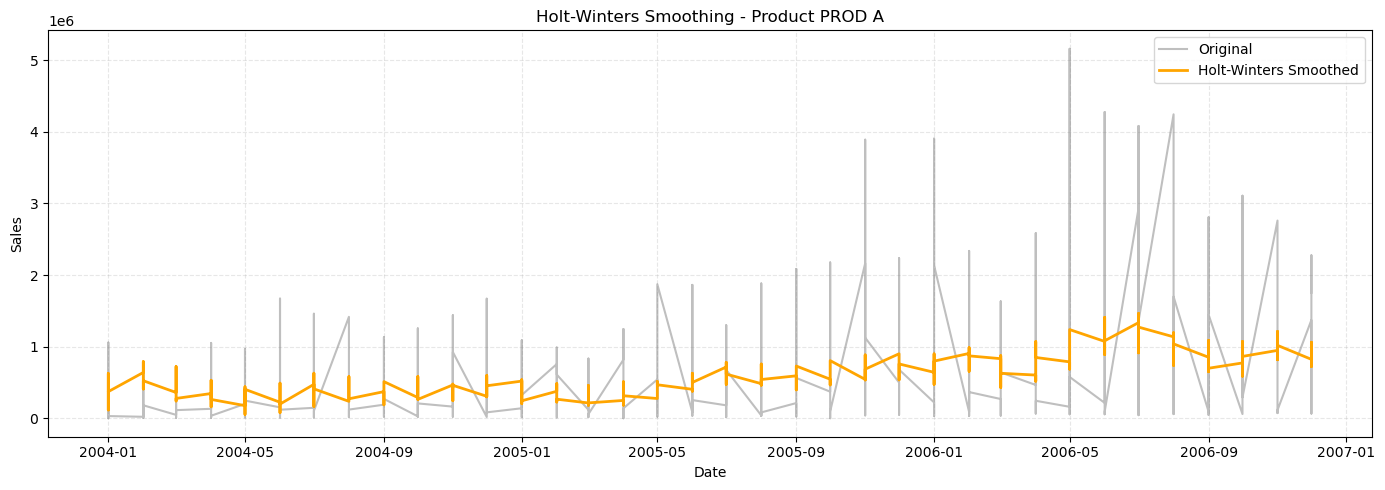

C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


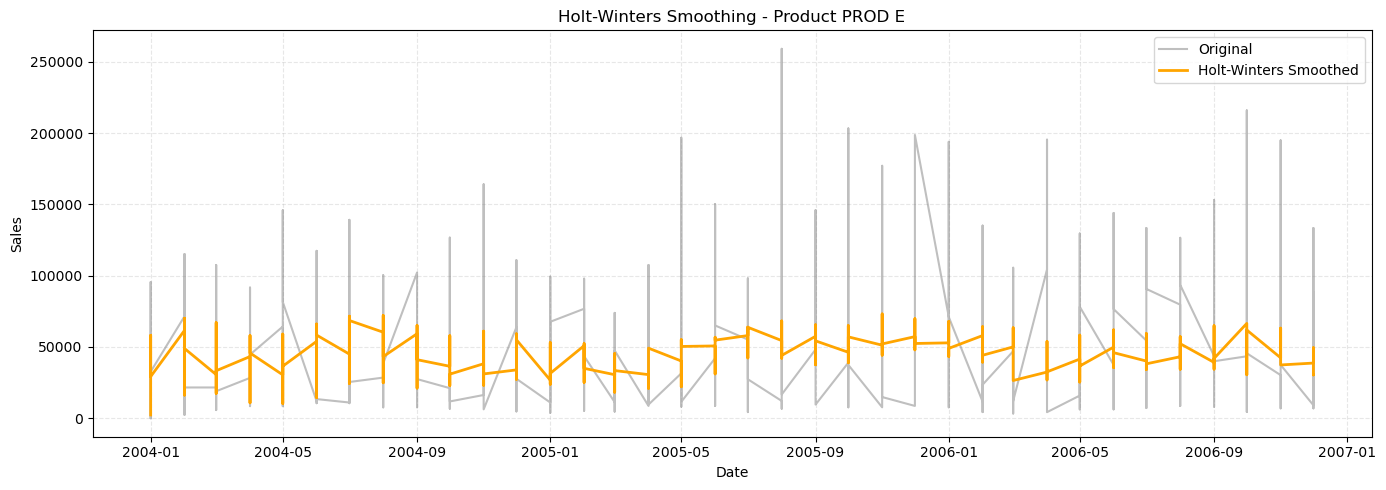

C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


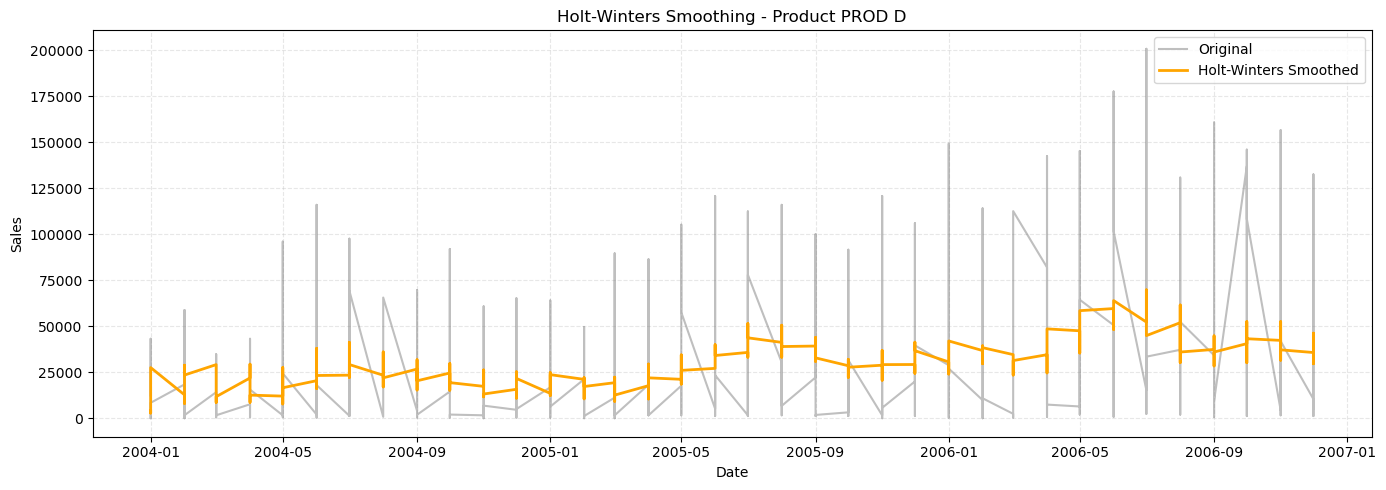

C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


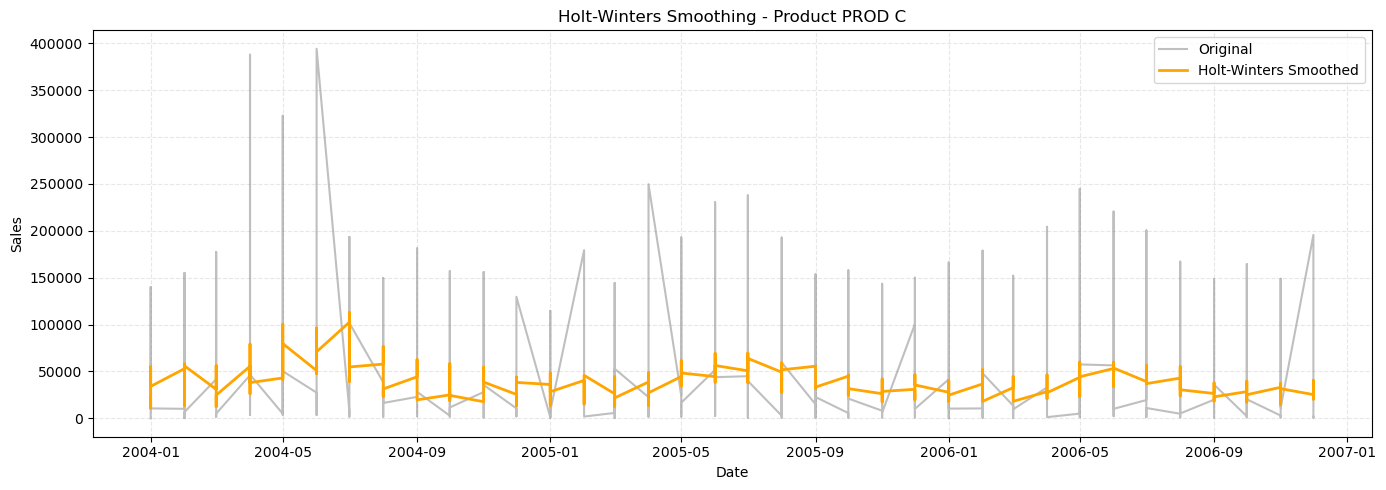

C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\niraj\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


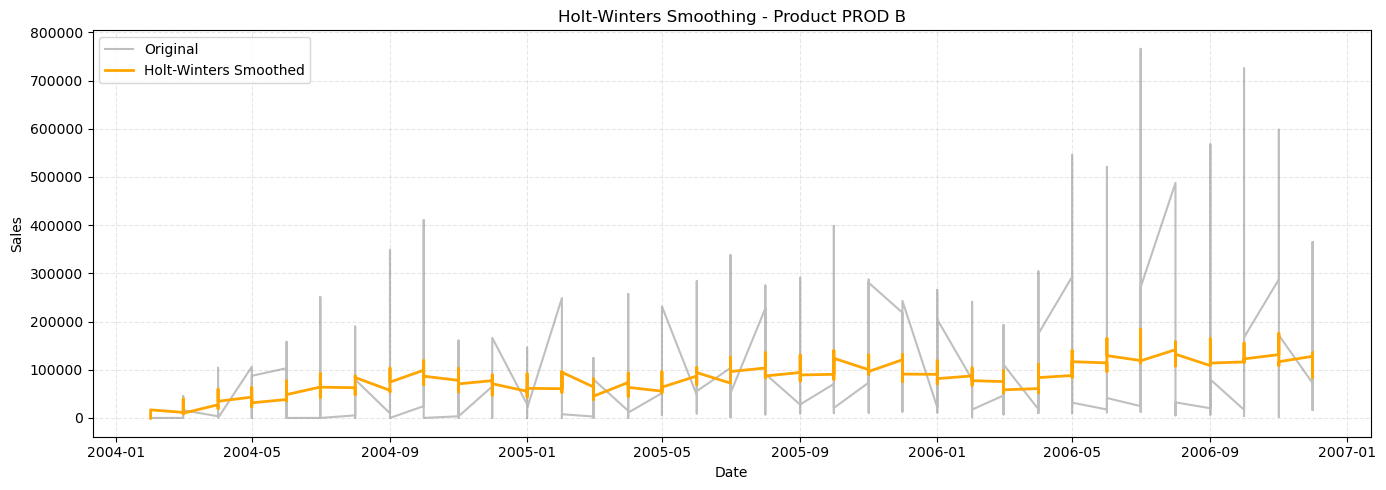

In [147]:
plot_holt_winters_per_product(df1, product_col='SKU', value_col='Sales', seasonal_periods=12)


In [ ]:
## Merging CPMNT and CPASF 

In [157]:
df1 = df1.reset_index()
df2 = df2.reset_index()

In [161]:
df = pd.concat([df1, df2], ignore_index=True)
df.to_csv('merged_data.csv', index=False)
